In [1]:
import Hmode_ML_Classifier
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import onnxruntime as ort

In [12]:
Model_Choice = 'ECE'
#ShotRange = [188859, 198759, 199850, 200324]
ShotRange = [203047, 203297, 204461, 202033, 202138, 203013, 203045, 203047, 203271, 204049, 204181, 204461, 204463, 200410, 200939, 201183,
            201454, 202029, 203011, 203036, 203092, 203110]
Times = np.arange(100,10000,100)
HM = Hmode_ML_Classifier.Hmode_Ml_Predictions(Model_Choice,ShotRange,Times)
Results = HM.Predict()

In [13]:
from toksearch_d3d import PtDataSignal
from toksearch import Pipeline
from toksearch import MdsSignal

pipeline = Pipeline(ShotRange)
Density_signal = MdsSignal(r'\Density','efit01')
pipeline.fetch('DENSITY', Density_signal)
records2 = pipeline.compute_multiprocessing()

In [14]:
Results[0]['Labeling_Errors']

{2200: 'High Density at time 2200',
 2300: 'High Density at time 2300',
 2400: 'High Density at time 2400',
 2500: 'High Density at time 2500',
 2600: 'High Density at time 2600',
 2700: 'High Density at time 2700',
 2800: 'High Density at time 2800',
 2900: 'High Density at time 2900',
 3000: 'High Density at time 3000',
 3100: 'High Density at time 3100',
 3200: 'High Density at time 3200',
 3300: 'High Density at time 3300',
 3400: 'High Density at time 3400',
 3500: 'High Density at time 3500',
 3600: 'High Density at time 3600',
 3700: 'High Density at time 3700',
 3800: 'High Density at time 3800',
 3900: 'High Density at time 3900',
 4000: 'High Density at time 4000',
 4600: 'High Density at time 4600',
 4700: 'High Density at time 4700',
 4800: 'High Density at time 4800',
 4900: 'High Density at time 4900',
 5000: 'High Density at time 5000',
 5100: 'High Density at time 5100',
 5200: 'High Density at time 5200',
 5300: 'High Density at time 5300',
 5400: 'High Density at time

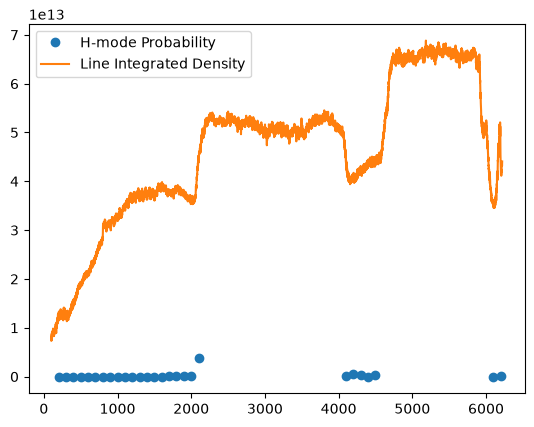

In [15]:
idx = 0

H_prob = []
for i in range(len(Results[idx]['LH_Prob'])):
    a = Results[idx]['LH_Prob'][i][1]
    H_prob.append(a)

plt.figure()
plt.plot(Results[idx]['Label_Times'],np.asarray(H_prob)*max(records2[idx]['DENSITY']['data']),'o',label='H-mode Probability')
plt.plot(records2[idx]['DENSITY']['times'],records2[idx]['DENSITY']['data'],label = 'Line Integrated Density')
plt.legend()

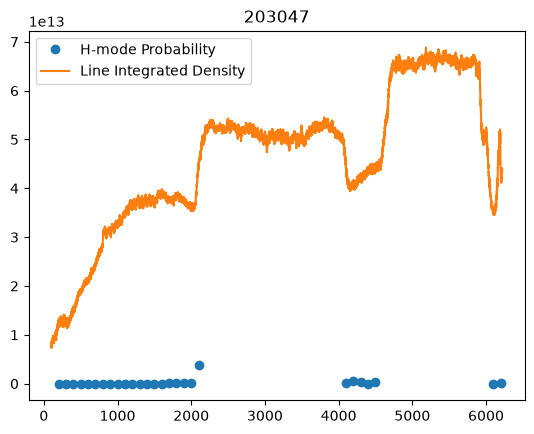

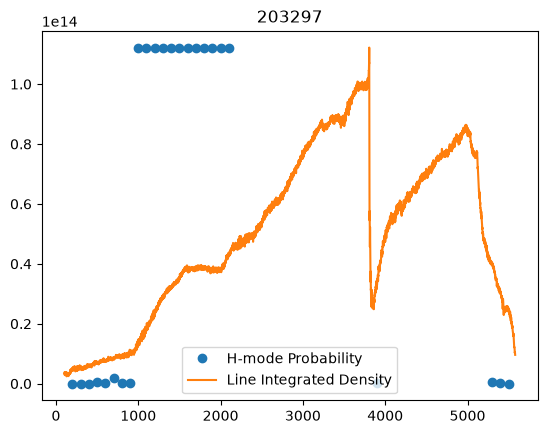

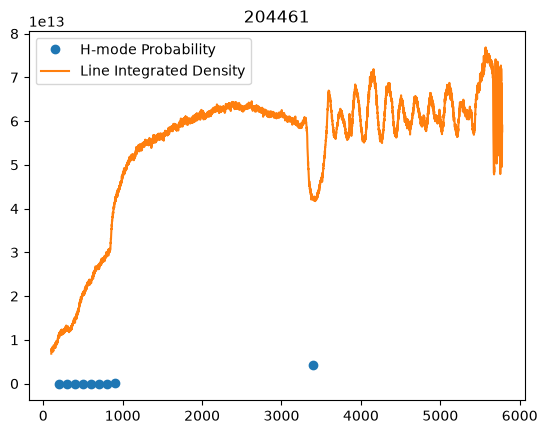

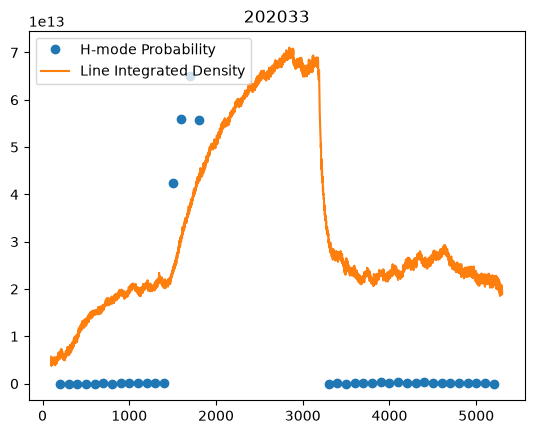

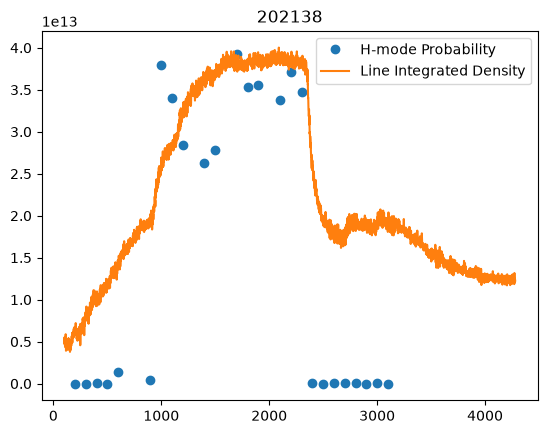

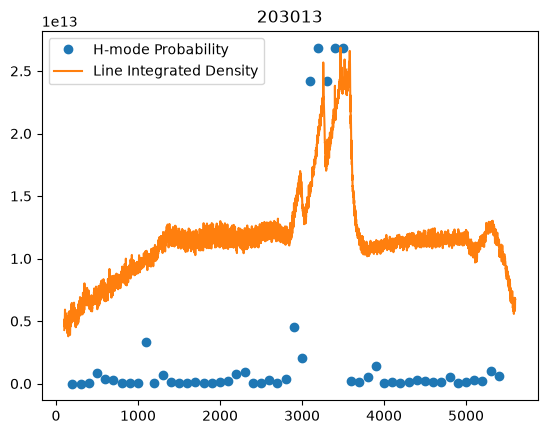

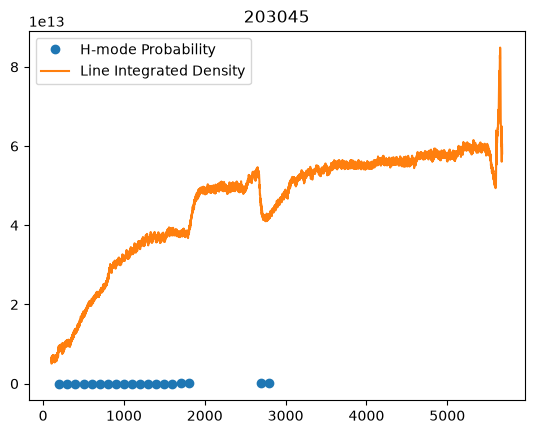

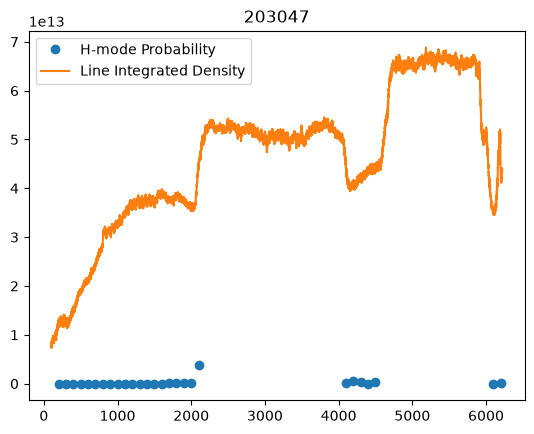

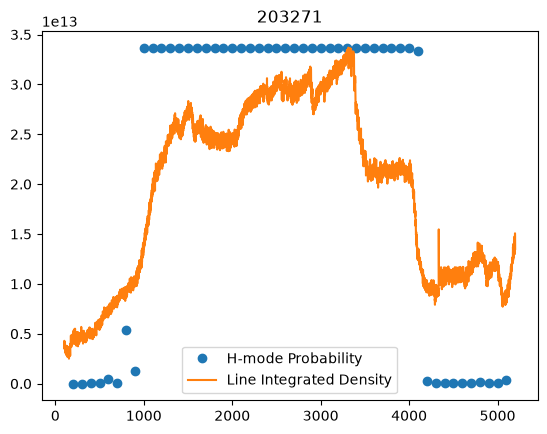

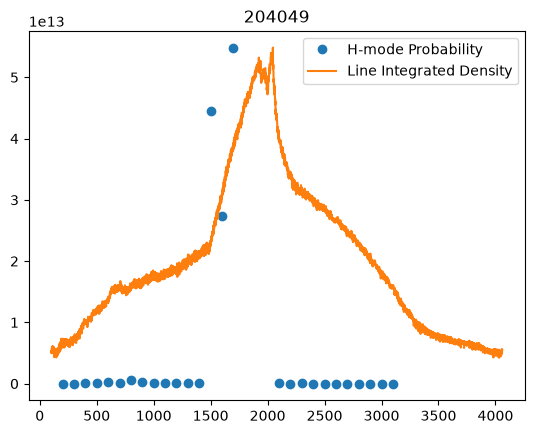

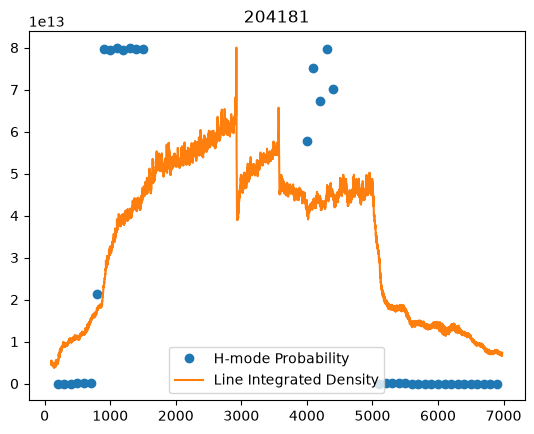

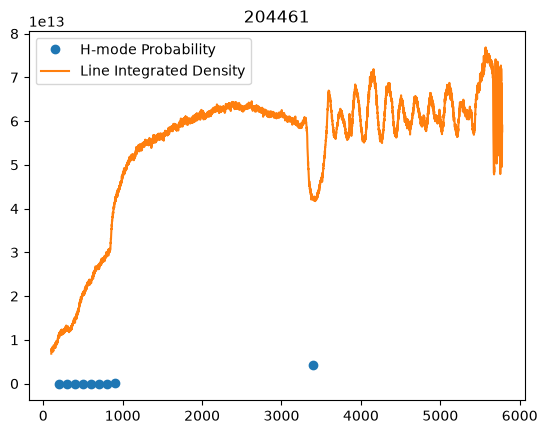

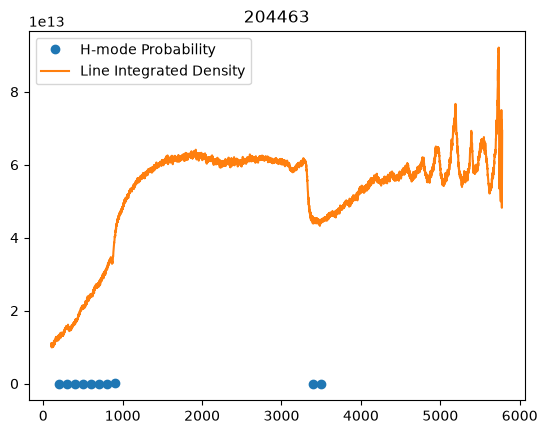

In [16]:

#idx = 0
for idx in range(0,13):
    H_prob = []
    for i in range(len(Results[idx]['LH_Prob'])):
        a = Results[idx]['LH_Prob'][i][1]
        H_prob.append(a)
    
    plt.figure()
    plt.plot(Results[idx]['Label_Times'],np.asarray(H_prob)*max(records2[idx]['DENSITY']['data']),'o',label='H-mode Probability')
    plt.plot(records2[idx]['DENSITY']['times'],records2[idx]['DENSITY']['data'],label = 'Line Integrated Density')
    plt.title(str(records2[idx]['shot']))
    plt.legend()
    plt.show()

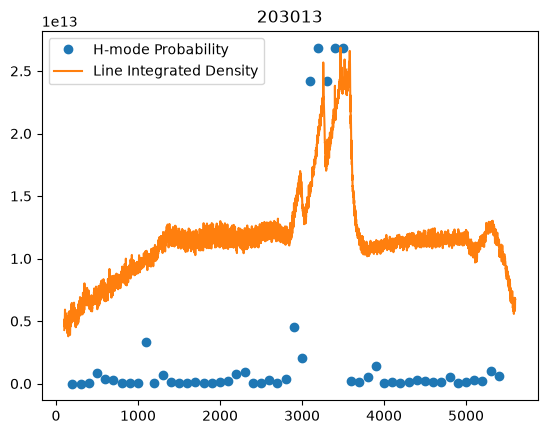

In [19]:
idx = 5

H_prob = []
for i in range(len(Results[idx]['LH_Prob'])):
    a = Results[idx]['LH_Prob'][i][1]
    H_prob.append(a)
Times = Results[idx]['Label_Times']
plt.figure()
plt.plot(Results[idx]['Label_Times'],np.asarray(H_prob)*max(records2[idx]['DENSITY']['data']),'o',label='H-mode Probability')
plt.plot(records2[idx]['DENSITY']['times'],records2[idx]['DENSITY']['data'],label = 'Line Integrated Density')
plt.title(str(records2[idx]['shot']))
plt.legend()

In [21]:
print(Times)
print(H_prob)

[ 200  300  400  500  600  700  800  900 1000 1100 1200 1300 1400 1500
 1600 1700 1800 1900 2000 2100 2200 2300 2400 2500 2600 2700 2800 2900
 3000 3100 3200 3300 3400 3500 3600 3700 3800 3900 4000 4100 4200 4300
 4400 4500 4600 4700 4800 4900 5000 5100 5200 5300 5400]
[5.0902366638183594e-05, 4.3272972106933594e-05, 0.0017803311347961426, 0.0325358510017395, 0.014311790466308594, 0.010370194911956787, 0.0031815767288208008, 0.0025559663772583008, 0.0023998618125915527, 0.12384772300720215, 0.0006926059722900391, 0.02593088150024414, 0.0040787458419799805, 0.00156325101852417, 0.002177596092224121, 0.005613565444946289, 0.0031232833862304688, 0.0020584464073181152, 0.0041280388832092285, 0.009003877639770508, 0.027415335178375244, 0.03592103719711304, 0.0030099153518676758, 0.001516878604888916, 0.011807382106781006, 0.0020155906677246094, 0.014531075954437256, 0.16942167282104492, 0.07711625099182129, 0.9001410603523254, 0.9992954730987549, 0.8992130160331726, 0.9989495873451233, 0.99

In [22]:
Results[idx]['Labeling_Errors']

{5500: 'Pedestal not observed at time 5500'}

In [23]:
Hmode_orig = [5.08008599e-02, 5.09023666e-05, 4.32729721e-05, 1.78033113e-03,
 3.25359702e-02, 1.43117905e-02, 1.03701949e-02, 3.18157673e-03,
 2.55596638e-03, 2.39986181e-03, 1.23847723e-01, 6.92605972e-04,
 2.59308815e-02, 4.07874584e-03, 1.56325102e-03, 2.17759609e-03,
 5.61356544e-03, 3.12328339e-03, 2.05844641e-03, 4.12803888e-03,
 9.00387764e-03, 2.74153352e-02, 3.59210372e-02, 3.00991535e-03,
 1.51687860e-03, 1.18073821e-02, 1.87331438e-03, 1.45310760e-02,
 1.69421673e-01, 7.71162510e-02, 9.98949587e-01, 9.98700023e-01,
 3.29416990e-03, 2.04897523e-02, 5.16906381e-02, 2.47019529e-03,
 5.02270460e-03, 3.19385529e-03, 5.83004951e-03, 1.13148689e-02,
 6.60771132e-03, 5.71739674e-03, 4.17387486e-03, 2.01097727e-02,
 2.15029716e-03, 3.37141752e-03]

In [24]:
Times_orig = [ 100.,  200.,  300.,  400.,  500.,  600.,  700.,  800.,  900., 1000., 1100., 1200.,
 1300., 1400., 1500., 1600., 1700., 1800., 1900., 2000., 2100., 2200., 2300., 2400.,
 2500., 2600., 2700., 2800., 2900., 3000., 3400., 3500., 3700., 3800., 3900., 4000.,
 4100., 4200., 4300., 4400., 4500., 4600., 4700., 4800., 4900., 5000.]

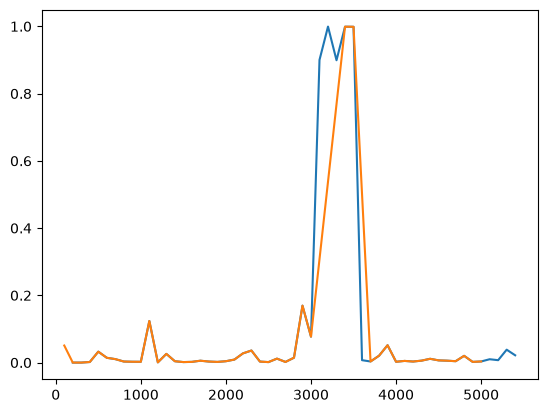

In [26]:
plt.plot(Times,H_prob)
plt.plot(Times_orig,Hmode_orig)

In [29]:
Result,idxes,idx_orig = np.intersect1d(Times, Times_orig,return_indices=True)

In [36]:
np.asarray(H_prob)[idxes]

array([5.09023666e-05, 4.32729721e-05, 1.78033113e-03, 3.25358510e-02,
       1.43117905e-02, 1.03701949e-02, 3.18157673e-03, 2.55596638e-03,
       2.39986181e-03, 1.23847723e-01, 6.92605972e-04, 2.59308815e-02,
       4.07874584e-03, 1.56325102e-03, 2.17759609e-03, 5.61356544e-03,
       3.12328339e-03, 2.05844641e-03, 4.12803888e-03, 9.00387764e-03,
       2.74153352e-02, 3.59210372e-02, 3.00991535e-03, 1.51687860e-03,
       1.18073821e-02, 2.01559067e-03, 1.45310760e-02, 1.69421673e-01,
       7.71162510e-02, 9.98949587e-01, 9.98700023e-01, 3.29416990e-03,
       2.04897523e-02, 5.16906381e-02, 2.47019529e-03, 5.02270460e-03,
       3.19385529e-03, 5.83004951e-03, 1.13148689e-02, 6.60771132e-03,
       5.71739674e-03, 4.17387486e-03, 2.01097727e-02, 2.15029716e-03,
       3.37141752e-03])

In [37]:
np.asarray(Hmode_orig)[idx_orig]

array([5.09023666e-05, 4.32729721e-05, 1.78033113e-03, 3.25359702e-02,
       1.43117905e-02, 1.03701949e-02, 3.18157673e-03, 2.55596638e-03,
       2.39986181e-03, 1.23847723e-01, 6.92605972e-04, 2.59308815e-02,
       4.07874584e-03, 1.56325102e-03, 2.17759609e-03, 5.61356544e-03,
       3.12328339e-03, 2.05844641e-03, 4.12803888e-03, 9.00387764e-03,
       2.74153352e-02, 3.59210372e-02, 3.00991535e-03, 1.51687860e-03,
       1.18073821e-02, 1.87331438e-03, 1.45310760e-02, 1.69421673e-01,
       7.71162510e-02, 9.98949587e-01, 9.98700023e-01, 3.29416990e-03,
       2.04897523e-02, 5.16906381e-02, 2.47019529e-03, 5.02270460e-03,
       3.19385529e-03, 5.83004951e-03, 1.13148689e-02, 6.60771132e-03,
       5.71739674e-03, 4.17387486e-03, 2.01097727e-02, 2.15029716e-03,
       3.37141752e-03])

In [38]:
#The Difference comes down to rounding errors, just about, multiple orders of magnitude of difference between the predictions
#and the error of predictions
np.asarray(H_prob)[idxes]-np.asarray(Hmode_orig)[idx_orig]

array([ 3.81835947e-14,  6.93359487e-15,  4.79614265e-12, -1.19198260e-07,
       -3.36914056e-11,  1.19567863e-11, -1.17919910e-12, -2.74169923e-12,
        2.59155284e-12,  7.20214166e-12,  2.90039043e-13,  2.44141513e-13,
        1.97998042e-12, -1.47583009e-12,  2.22412106e-12,  4.94628904e-12,
       -3.76953113e-12, -2.68188466e-12,  3.20922889e-12, -2.29491773e-13,
       -2.16247575e-11, -2.88696150e-12,  1.86767572e-12,  4.88891609e-12,
        6.78100631e-12,  1.42276288e-04, -4.55627445e-11, -1.78955073e-10,
       -8.17870771e-12,  3.45123263e-10, -3.02551317e-10,  2.80151380e-12,
       -7.36694386e-12, -3.46618637e-11,  3.42651385e-12,  1.28784223e-12,
       -4.35546868e-12,  4.77050777e-12,  2.70019528e-11, -4.84497078e-12,
       -3.85498057e-12, -4.95849629e-12, -1.78100590e-11,  4.91699216e-12,
        2.43042001e-12])